# Marker Fractions Along Crypt Axes

This notebook contains the graph-hop and crypt-axis marker-fraction figures that were split out of `plot_crypt_compositions.ipynb`. It reuses the same dataset configuration and crypt inspection table construction so it can be run independently.


In [11]:
# If you edit paths or grouping, re-run this cell and everything below.
import os
import warnings
import glob
from functools import lru_cache

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from organograph.graph.io import load_cell_graph
from organograph.graph.access import graph_get

from organograph.crypts.analysis_markers import (
    bin_marker_positivity,
    get_marker_counts_per_patch,
    assign_coexpression_category,
)
from organograph.crypts.filters import filter_crypts_by_markers
from organograph.io_utils.segmentation_io import (
    load_graph_crypt_segmentation,
    load_mesh_crypt_segmentation,
)
from organograph.mesh.OrganoidMesh import OrganoidMesh
from organograph.mesh.hks import compute_hks
from organograph.plotting.colors import resolve_category_colors
from organograph.skeleton.build import (
    _low_pass_smoothed_mesh_for_detection,
    _select_hks_tips_from_axis,
)


## Configuration

Edit dataset paths, marker filters, and plotting targets here. `DATA_SPECS` may contain multiple datasets with the same display label; downstream tables group by that label.


In [12]:
# -----------------------
# CONFIG
# -----------------------
PROJECT_ROOT = os.path.abspath(os.getcwd())
if os.path.basename(PROJECT_ROOT) in {"notebooks", "notebooks_dev", "legacy"}:
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
DATA_ROOT    = os.path.join(PROJECT_ROOT, "..", "NicoleData")

NOTEBOOK_NAME = "plot_marker_fractions_along_crypt_axes"
EXPORT_DIR = os.path.join(PROJECT_ROOT, "exports", NOTEBOOK_NAME)
os.makedirs(EXPORT_DIR, exist_ok=True)


def export_figure(fig, filename):
    """Save a Matplotlib figure as a tightly cropped PDF in the notebook export folder."""
    safe_name = "".join(
        char if char.isalnum() or char in {"_", "-"} else "_"
        for char in str(filename)
    ).strip("_")
    path = os.path.join(EXPORT_DIR, f"{safe_name}.pdf")
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

# For each dataset you can now specify:
#   - dataset: dataset folder
#   - seg_subdir: segmentation folder inside that dataset
#   - graph_subdir: graph folder inside that dataset
#   - timepoints: list of timepoints to include (or None for auto-discover)
#   - label: label shown on plots
DATA_SPECS = [
    # {
    #     "dataset": "20250929",
    #     "seg_subdir": "crypt_segmentations_graph_3p5selected",
    #     "graph_subdir": "graphs_preprocessed_exclusive",
    #     "timepoints": ["day3p5"],
    #     "label": "day 3.5 (good)",
    # },
    {
        "dataset": "20250929",
        "seg_subdir": "crypt_segmentations_graph",
        "graph_subdir": "graphs_preprocessed",
        "timepoints": ["day3p5"],
        "label": "day 3.5",
    },
    {
        "dataset": "20250929",
        "seg_subdir": "crypt_segmentations_graph",
        "graph_subdir": "graphs_preprocessed",
        "timepoints": ["day4p5", "day4p5-more"],
        "label": "day 4.5",
    },
    {
        "dataset": "20251201",
        "seg_subdir": "crypt_segmentations_graph",
        "graph_subdir": "graphs_preprocessed",
        "timepoints": ["day4p5"],
        "label": "day 4.5",
    },
]

# Optional marker names used only for coexpression_cat if present in a given graph.
COEX_MARKERS = {
    "LGR5": "LGR5",
    "Sero": "Serotonin",
    "Lyso": "Lysozyme",
}

# Optional crypt filter settings.
# This version resolves marker indices separately inside each graph.
USE_CRYPT_FILTER = True

CRYPT_FILTER_KW = dict(
    pos_marker_names=['LGR5', 'Chroma', 'Agr2', 'Serotonin', 'Lysozyme'],      # e.g. ["LGR5"]
    neg_marker_names=["AldoB"],
    pos_min=1,
    neg_min=2,
    roi_frac=0.75,
    require_all_pos=False,
)

MIN_POSITIVE = 1
POS_THRESHOLD = 1


TARGET_MARKERS = ["LGR5", "Serotonin", "Lysozyme"]
DERIVED_MARKER_GROUPS = {}
NORMALIZED_DISTANCE_BIN_EDGES = np.linspace(0.0, 1.2, 10)
GRAPH_HOP_MAX = 10


def ordered_unique(values):
    seen = set()
    out = []
    for value in values:
        if value not in seen:
            seen.add(value)
            out.append(value)
    return out


SAMPLE_ORDER = ordered_unique(d["label"] for d in DATA_SPECS)


## Load Crypt-Level Table

The inspection table is one row per retained crypt. It loads each graph segmentation, resolves its graph, applies the optional marker-aware crypt filter, and records marker counts plus saved morphology descriptors.


In [13]:
from organograph.io_utils.cells_table import harmonize_markers

def discover_timepoints(seg_dir):
    if not os.path.isdir(seg_dir):
        return []
    tps = []
    for name in sorted(os.listdir(seg_dir)):
        p = os.path.join(seg_dir, name)
        if os.path.isdir(p) and glob.glob(os.path.join(p, "*.npz")):
            tps.append(name)
    return tps


def _seg_get(seg, *keys, default=None):
    for k in keys:
        if k in seg:
            return seg[k]
    return default


def _safe_array(x):
    if x is None:
        return None
    return np.asarray(x)


def _as_list_of_lists(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [list(xx) for xx in x]
    if isinstance(x, np.ndarray) and x.dtype == object:
        return [list(xx) for xx in x.tolist()]
    return [list(xx) for xx in x]


def _infer_marker_names(G):
    """
    Read marker names from the graph itself.
    """
    for k in ["marker_names", "markers", "marker_cols"]:
        v = G.graph.get(k, None)
        if v is not None:
            return list(v)

    markers_bin = graph_get(G, "markers_bin")
    n_markers = markers_bin.shape[1]
    return [f"marker_{i}" for i in range(n_markers)]


def _infer_label_uid(G, fallback=None):
    return G.graph.get("label_uid", None) or fallback


@lru_cache(maxsize=None)
def load_graph_cached(graph_path):
    return load_cell_graph(graph_path)


def build_dataset_paths(data_spec, data_root):
    dataset = data_spec["dataset"]

    seg_subdir = data_spec.get("seg_subdir", "crypt_segmentations_graph")
    graph_subdir = data_spec.get("graph_subdir", "graphs_preprocessed")

    seg_dir = os.path.join(data_root, dataset, seg_subdir)
    graphs_dir = os.path.join(data_root, dataset, graph_subdir)

    return seg_dir, graphs_dir


def resolve_graph_path(seg, graphs_dir):
    """
    Prefer the graph path stored in the segmentation if it exists.
    Otherwise try to rebuild it relative to the dataset-specific graphs_dir.
    """
    graph_path = seg.get("graph_path", None)

    if graph_path is not None and os.path.exists(graph_path):
        return graph_path

    if graph_path is None:
        return None

    # fallback: use basename inside graphs_dir
    base = os.path.basename(graph_path)
    candidate = os.path.join(graphs_dir, base)
    if os.path.exists(candidate):
        return candidate

    return graph_path


def resolve_mesh_path(seg, dataset_root=None):
    mesh_path = seg.get("mesh_path", None)
    if mesh_path is None:
        return None
    return mesh_path


def iter_selected_seg_paths(data_specs, data_root, verbose=True):
    """
    Iterate through all requested segmentation files.
    Yields dicts with:
      dataset, timepoint, label, seg_path, seg_dir, graphs_dir
    """
    for ds in data_specs:
        seg_dir, graphs_dir = build_dataset_paths(ds, data_root)

        tps = ds.get("timepoints", None)
        if tps is None:
            tps = discover_timepoints(seg_dir)

        for tp in tps:
            tp_dir = os.path.join(seg_dir, tp)
            seg_paths = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))

            if verbose and len(seg_paths) == 0:
                print(f"[warn] no segmentation files found in: {tp_dir}")

            for seg_path in seg_paths:
                yield {
                    "dataset": ds["dataset"],
                    "timepoint": tp,
                    "label": ds.get("label", f'{ds["dataset"]}:{tp}'),
                    "seg_path": seg_path,
                    "seg_dir": seg_dir,
                    "graphs_dir": graphs_dir,
                }
                

def infer_common_markers(data_specs, data_root, verbose=True):
    """
    Intersect marker names across all selected graphs.
    Returns common markers in the order they first appear.
    """
    marker_sets = []
    ordered_first = None

    for item in iter_selected_seg_paths(data_specs, data_root, verbose=verbose):
        seg_path = item["seg_path"]
        graphs_dir = item["graphs_dir"]

        try:
            seg = load_graph_crypt_segmentation(seg_path)
            graph_path = resolve_graph_path(seg, graphs_dir=graphs_dir)
            G = load_graph_cached(graph_path)
            marker_names = _infer_marker_names(G)
        except Exception as e:
            if verbose:
                print(f"[skip common-marker scan] {seg_path}: {e}")
            continue

        marker_set = set(marker_names)
        marker_sets.append(marker_set)

        if ordered_first is None:
            ordered_first = list(marker_names)

    if len(marker_sets) == 0:
        return []

    common = set.intersection(*marker_sets)
    if ordered_first is None:
        return sorted(common)

    return [m for m in ordered_first if m in common]


def make_graph_aware_crypt_filter(
    pos_marker_names=None,
    neg_marker_names=None,
    pos_min=2,
    neg_min=2,
    roi_frac=0.65,
    require_all_pos=True,
):
    pos_marker_names = [] if pos_marker_names is None else list(pos_marker_names)
    neg_marker_names = [] if neg_marker_names is None else list(neg_marker_names)

    def _crypt_filter(G, crypts_graph, seg, marker_names):
        name_to_idx = {m: i for i, m in enumerate(marker_names)}

        pos_markers = [name_to_idx[m] for m in pos_marker_names if m in name_to_idx]
        neg_markers = [name_to_idx[m] for m in neg_marker_names if m in name_to_idx]

        # If a requested positive marker is absent, require nothing from it.
        # If a requested negative marker is absent, also ignore it.
        return filter_crypts_by_markers(
            G,
            crypts_graph,
            pos_markers=pos_markers,
            neg_markers=neg_markers,
            pos_min=pos_min,
            neg_min=neg_min,
            roi_frac=roi_frac,
            dist_bottom=seg["d_crypts_graph"],
            require_all_pos=require_all_pos,
        )

    return _crypt_filter


def lighten_color(rgb_or_hex, amount=0.65):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))


def load_seg_cached(seg_path):
    return load_graph_crypt_segmentation(seg_path)


def get_roi_cells_for_crypt(crypt_cells, dist_bottom, crypt_number=None, roi_frac=None):
    """
    Restrict crypt cells to those with dist_bottom <= roi_frac.

    Supports:
      - dist_bottom shape (N_cells,)          : one global per-cell array
      - dist_bottom shape (K_crypts, N_cells) : one row per crypt

    Parameters
    ----------
    crypt_cells : list[int]
        Cell ids belonging to this crypt.
    dist_bottom : array-like
        Either shape (N_cells,) or (K_crypts, N_cells).
    crypt_number : int or None
        Required when dist_bottom has shape (K_crypts, N_cells).
        Should be the original crypt index in the segmentation.
    roi_frac : float or None
        If None, keep all crypt cells.
        Otherwise keep only cells with dist_bottom <= roi_frac.

    Returns
    -------
    roi_cells : np.ndarray of int
    """
    idx = np.asarray(list(crypt_cells), dtype=np.int64)

    if roi_frac is None:
        return idx

    db = np.asarray(dist_bottom, dtype=float)

    if db.ndim == 1:
        db_row = db

    elif db.ndim == 2:
        if crypt_number is None:
            raise ValueError(
                "crypt_number is required when dist_bottom has shape (K_crypts, N_cells)."
            )
        if crypt_number < 0 or crypt_number >= db.shape[0]:
            raise ValueError(
                f"crypt_number={crypt_number} out of range for dist_bottom with shape {db.shape}."
            )
        db_row = db[int(crypt_number)]

    else:
        raise ValueError(
            "dist_bottom must have shape (N_cells,) or (K_crypts, N_cells)."
        )

    if np.any(idx < 0) or np.any(idx >= len(db_row)):
        raise ValueError("crypt_cells contains indices out of range for dist_bottom.")

    dvals = db_row[idx]
    keep = np.isfinite(dvals) & (dvals <= float(roi_frac))
    return idx[keep]


def compute_crypt_shape_metrics(seg, crypt_idx, fullness_power=1.0):
    """
    Compute scalar shape metrics for one crypt from segmentation data.

    Metrics
    -------
    crypt_length : float
        L

    crypt_cmax : float
        max circumference inside crypt (d_discretized <= 1)

    crypt_slenderness : float
        L / C_max

    crypt_fullness : float
        Weighted mean normalized position of circumference:
            mu = (∫ d * C(d)^p dd) / (∫ C(d)^p dd)

    crypt_circ_pos_var : float
        Weighted variance of circumference position:
            var = (∫ (d-mu)^2 * C(d)^p dd) / (∫ C(d)^p dd)

    crypt_circ_pos_spread : float
        sqrt(var)

    crypt_circ_pos_spread_norm : float
        2 * sqrt(var), roughly scaled to [0, 1]
    """
    L_crypts = _safe_array(_seg_get(seg, "L_crypts", default=None))
    circumference_crypts = _safe_array(_seg_get(seg, "circumference_crypts", default=None))
    d_discretized = _safe_array(_seg_get(seg, "d_discretized", default=None))

    out = {
        "crypt_length": np.nan,
        "crypt_cmax": np.nan,
        "crypt_slenderness": np.nan,
        "crypt_fullness": np.nan,
        "crypt_circ_pos_var": np.nan,
        "crypt_circ_pos_spread": np.nan,
        "crypt_circ_pos_spread_norm": np.nan,
    }

    if L_crypts is None or circumference_crypts is None or d_discretized is None:
        return out

    if crypt_idx < 0 or crypt_idx >= len(L_crypts):
        return out

    try:
        L = float(L_crypts[crypt_idx])
        C = np.asarray(circumference_crypts[crypt_idx], dtype=float)
        d = np.asarray(d_discretized, dtype=float)
    except Exception:
        return out

    if C.ndim != 1 or d.ndim != 1 or len(C) != len(d):
        return out

    keep = np.isfinite(d) & np.isfinite(C) & (d <= 1.0)
    if not np.any(keep):
        return out

    d_roi = d[keep]
    C_roi = C[keep]

    order = np.argsort(d_roi)
    d_roi = d_roi[order]
    C_roi = C_roi[order]

    C_max = float(np.nanmax(C_roi)) if len(C_roi) > 0 else np.nan
    slenderness = float(L / C_max) if np.isfinite(L) and C_max > 0 else np.nan

    p = float(fullness_power)
    if p <= 0:
        raise ValueError("fullness_power must be > 0")

    W = C_roi ** p
    denom = np.trapezoid(W, d_roi)

    if denom > 0:
        mu = float(np.trapezoid(d_roi * W, d_roi) / denom)
        var = float(np.trapezoid(((d_roi - mu) ** 2) * W, d_roi) / denom)
        var = max(var, 0.0)
        spread = float(np.sqrt(var))
        spread_norm = float(2.0 * spread)
    else:
        mu = np.nan
        var = np.nan
        spread = np.nan
        spread_norm = np.nan

    return {
        "crypt_length": L,
        "crypt_cmax": C_max,
        "crypt_slenderness": slenderness,
        "crypt_fullness": mu,
        "crypt_circ_pos_var": var,
        "crypt_circ_pos_spread": spread,
        "crypt_circ_pos_spread_norm": spread_norm,
    }


### Inspect Stored Segmentation Variables

This quick check loads one segmentation from each configured dataset/timepoint group and prints the variables stored in the `.npz` file, including shape and dtype.


In [14]:
def describe_segmentation_variables(seg):
    rows = []
    for key in sorted(seg.keys()):
        value = seg[key]
        arr = np.asarray(value)
        rows.append({
            "variable": key,
            "shape": tuple(arr.shape),
            "dtype": str(arr.dtype),
        })
    return pd.DataFrame(rows)


def print_one_segmentation_variables_per_dataset(data_specs=DATA_SPECS, data_root=DATA_ROOT):
    seen = set()
    for item in iter_selected_seg_paths(data_specs, data_root, verbose=False):
        group_key = (item["dataset"], item["timepoint"], item["label"])
        if group_key in seen:
            continue
        seen.add(group_key)

        seg = load_graph_crypt_segmentation(item["seg_path"])
        print("=" * 88)
        print(f"dataset={item['dataset']} | timepoint={item['timepoint']} | label={item['label']}")
        print(f"segmentation={item['seg_path']}")
        display(describe_segmentation_variables(seg))

    if not seen:
        print("No segmentation files found for the configured DATA_SPECS.")


print_one_segmentation_variables_per_dataset()


dataset=20250929 | timepoint=day3p5 | label=day 3.5
segmentation=/home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData/20250929/crypt_segmentations_graph/day3p5/day3p5_A01_1.npz


,variable,shape,dtype
0,L_crypts,"(2,)",float64
1,bottom_vertex_ids,"(2,)",int64
2,circumference_crypts,"(2, 200)",float64
3,crypt_constrictions,"(2,)",float64
4,crypt_elongations,"(2,)",float64
5,crypts_graph,"(2,)",object
6,curvature_gauss_graph,"(165,)",float64
7,d_crypts_graph,"(2, 165)",float64
8,d_discretized,"(200,)",float64
9,graph_patch_sizes,"(2,)",int64


dataset=20250929 | timepoint=day4p5 | label=day 4.5
segmentation=/home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData/20250929/crypt_segmentations_graph/day4p5/day4p5_A06_11.npz


,variable,shape,dtype
0,L_crypts,"(2,)",float64
1,bottom_vertex_ids,"(2,)",int64
2,circumference_crypts,"(2, 200)",float64
3,crypt_constrictions,"(2,)",float64
4,crypt_elongations,"(2,)",float64
5,crypts_graph,"(2,)",object
6,curvature_gauss_graph,"(278,)",float64
7,d_crypts_graph,"(2, 278)",float64
8,d_discretized,"(200,)",float64
9,graph_patch_sizes,"(2,)",int64


dataset=20250929 | timepoint=day4p5-more | label=day 4.5
segmentation=/home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData/20250929/crypt_segmentations_graph/day4p5-more/day4p5-more_C01_1.npz


,variable,shape,dtype
0,L_crypts,"(0,)",float64
1,bottom_vertex_ids,"(0,)",int64
2,circumference_crypts,"(0, 200)",float64
3,crypt_constrictions,"(0,)",float64
4,crypt_elongations,"(0,)",float64
5,crypts_graph,"(0,)",float64
6,curvature_gauss_graph,"(441,)",float64
7,d_crypts_graph,"(0, 441)",float64
8,d_discretized,"(200,)",float64
9,graph_patch_sizes,"(0,)",int64


dataset=20251201 | timepoint=day4p5 | label=day 4.5
segmentation=/home/fmoller/Projects/LearningOrganoids/OrganoGraph/../NicoleData/20251201/crypt_segmentations_graph/day4p5/day4p5_B02_100.npz


,variable,shape,dtype
0,L_crypts,"(2,)",float64
1,bottom_vertex_ids,"(2,)",int64
2,circumference_crypts,"(2, 200)",float64
3,crypt_constrictions,"(2,)",float64
4,crypt_elongations,"(2,)",float64
5,crypts_graph,"(2,)",object
6,curvature_gauss_graph,"(264,)",float64
7,d_crypts_graph,"(2, 264)",float64
8,d_discretized,"(200,)",float64
9,graph_patch_sizes,"(2,)",int64


## Build Crypt Inspection Table

The distance-profile figures use the same crypt-level table as the composition notebook: one row per retained crypt, with graph, segmentation, and marker-count metadata attached.


In [15]:
def build_inspection_table_multi(
    data_specs,
    data_root,
    verbose=True,
    min_positive=1,
    pos_threshold=1,
    coex_markers=None,
    crypt_filter=None,
):
    rows_out = []

    coex_markers = {} if coex_markers is None else dict(coex_markers)

    for item in iter_selected_seg_paths(data_specs, data_root, verbose=verbose):
        dataset = item["dataset"]
        tp = item["timepoint"]
        label = item["label"]
        seg_path = item["seg_path"]
        graphs_dir = item["graphs_dir"]

        # load segmentation
        try:
            seg = load_graph_crypt_segmentation(seg_path)
        except Exception as e:
            if verbose:
                print(f"[skip] could not load segmentation {seg_path}: {e}")
            continue

        # resolve graph path using dataset-specific graphs_dir
        graph_path = resolve_graph_path(seg, graphs_dir=graphs_dir)

        # load graph
        try:
            G = load_graph_cached(graph_path)
        except Exception as e:
            if verbose:
                print(f"[skip] could not load graph {graph_path}: {e}")
            continue

        marker_names = _infer_marker_names(G)
        name_to_idx = {m: i for i, m in enumerate(marker_names)}

        crypts_graph = _as_list_of_lists(
            _seg_get(seg, "crypts_graph", "crypts_ll", "graph_crypts_ll", default=[])
        )
        constrictions = _safe_array(_seg_get(seg, "crypt_constrictions", default=None))
        elongations = _safe_array(_seg_get(seg, "crypt_elongations", "crypt_elongationss", default=None))
        graph_patch_sizes = _safe_array(_seg_get(seg, "graph_patch_sizes", default=None))

        label_uid = _seg_get(seg, "label_uid", default=None)
        label_uid = _infer_label_uid(G, fallback=label_uid)

        n_crypts = len(crypts_graph)

        # run filter once
        if crypt_filter is None:
            keep_idx = np.arange(n_crypts, dtype=np.int64)
        else:
            keep = crypt_filter(G, crypts_graph, seg, marker_names)

            if isinstance(keep, np.ndarray) and keep.dtype == bool:
                if len(keep) != n_crypts:
                    raise ValueError(
                        f"crypt_filter returned boolean mask of length {len(keep)}, "
                        f"expected {n_crypts}"
                    )
                keep_idx = np.flatnonzero(keep)
            else:
                keep_idx = np.asarray(keep, dtype=np.int64)

        if keep_idx.ndim != 1:
            raise ValueError("keep_idx must be a 1D array of crypt indices")
        if len(keep_idx) > 0:
            if keep_idx.min() < 0 or keep_idx.max() >= n_crypts:
                raise ValueError("crypt_filter returned out-of-range crypt indices")

        crypts_graph_f = [crypts_graph[j] for j in keep_idx]
        constrictions_f = constrictions[keep_idx] if constrictions is not None else None
        elongations_f = elongations[keep_idx] if elongations is not None else None
        graph_patch_sizes_f = graph_patch_sizes[keep_idx] if graph_patch_sizes is not None else None
        orig_crypt_numbers_f = keep_idx

        # coexpression indices if present in this graph
        i_LGR5 = name_to_idx.get(coex_markers.get("LGR5", ""), None)
        i_Sero = name_to_idx.get(coex_markers.get("Sero", ""), None)
        i_Lyso = name_to_idx.get(coex_markers.get("Lyso", ""), None)

        for local_idx, crypt_cells in enumerate(crypts_graph_f):
            crypt_cells = list(crypt_cells)
            if len(crypt_cells) == 0:
                continue

            orig_j = int(orig_crypt_numbers_f[local_idx])

            shape_metrics = compute_crypt_shape_metrics(seg, orig_j)

            num_pos_cells, num_cells = get_marker_counts_per_patch(G, crypt_cells)
            num_pos_cells = np.asarray(num_pos_cells, dtype=np.int64)

            if num_pos_cells.shape[0] != len(marker_names):
                raise ValueError(
                    f"Marker count mismatch for {seg_path}: "
                    f"counts have length {num_pos_cells.shape[0]}, "
                    f"marker_names has length {len(marker_names)}"
                )

            has_marker = (num_pos_cells >= min_positive).astype(np.int64)

            if None not in (i_LGR5, i_Sero, i_Lyso):
                coexpression_cat = assign_coexpression_category(
                    G,
                    crypt_cells,
                    i_LGR5,
                    i_Sero,
                    i_Lyso,
                    pos_threshold=pos_threshold,
                )
            else:
                coexpression_cat = np.nan

            constr = (
                float(constrictions_f[local_idx])
                if constrictions_f is not None and local_idx < len(constrictions_f)
                else np.nan
            )

            row = {
                "dataset": dataset,
                "timepoint": tp,
                "sample_label": label,
                "label_uid": label_uid,
                "crypt_number": orig_j,
                "crypt_number_filtered": local_idx,
                "graph_path": graph_path,
                "mesh_path": seg.get("mesh_path", None),
                "seg_path": seg_path if os.path.exists(seg_path) else None,
                "has_seg": bool(os.path.exists(seg_path)),
                "num_cells": int(num_cells),
                "constriction": constr,
                "elongation": (
                    float(elongations_f[local_idx])
                    if elongations_f is not None and local_idx < len(elongations_f)
                    else np.nan
                ),
                "graph_patch_size": (
                    int(graph_patch_sizes_f[local_idx])
                    if graph_patch_sizes_f is not None and local_idx < len(graph_patch_sizes_f)
                    else int(num_cells)
                ),
                "coexpression_cat": coexpression_cat,
                "is_budded": (constr > 0) if not np.isnan(constr) else np.nan,
                "crypt_cells": crypt_cells,
                "graph_marker_names": tuple(marker_names),
                "crypt_length": shape_metrics["crypt_length"],
                "crypt_cmax": shape_metrics["crypt_cmax"],
                "crypt_slenderness": shape_metrics["crypt_slenderness"],
                "crypt_fullness": shape_metrics["crypt_fullness"],
                "crypt_circ_pos_var": shape_metrics["crypt_circ_pos_var"],
                "crypt_circ_pos_spread": shape_metrics["crypt_circ_pos_spread"],
                "crypt_circ_pos_spread_norm": shape_metrics["crypt_circ_pos_spread_norm"],
            }

            for k, mk in enumerate(marker_names):
                row[f"{mk}_n_pos"] = int(num_pos_cells[k])
                row[f"{mk}_frac_pos"] = float(num_pos_cells[k] / num_cells) if num_cells > 0 else np.nan
                row[f"{mk}_has"] = int(has_marker[k])

            rows_out.append(row)

    df = pd.DataFrame(rows_out)

    if len(df) == 0:
        return df

    has_cols = [c for c in df.columns if c.endswith("_has")]
    if len(has_cols) > 0:
        df["n_markers_present"] = df[has_cols].fillna(0).sum(axis=1)

    return df


In [16]:
crypt_filter = None
if USE_CRYPT_FILTER:
    crypt_filter = make_graph_aware_crypt_filter(**CRYPT_FILTER_KW)


common_markers = infer_common_markers(DATA_SPECS, DATA_ROOT, verbose=True)
print("COMMON MARKERS =", common_markers)

inspection_df = build_inspection_table_multi(
    data_specs=DATA_SPECS,
    data_root=DATA_ROOT,
    verbose=True,
    min_positive=MIN_POSITIVE,
    pos_threshold=POS_THRESHOLD,
    coex_markers=COEX_MARKERS,
    crypt_filter=crypt_filter,
)

print("inspection_df shape:", inspection_df.shape)
inspection_df.head()

print("sample groups:", SAMPLE_ORDER)


COMMON MARKERS = ['LGR5', 'Chroma', 'AldoB', 'Agr2', 'Serotonin', 'Lysozyme']
inspection_df shape: (848, 59)
sample groups: ['day 3.5', 'day 4.5']


## Marker Fractions Along Crypt Axes

Only `LGR5`, `Serotonin`, and `Lysozyme` panels are shown. Curve colors use Matplotlib's standard group color cycle so timepoints are easier to distinguish.


In [17]:
def _marker_alias_candidates(marker_name):
    marker_name = str(marker_name)
    aliases = {
        "ChromA": ["ChromA", "Chroma", "Chromogranin A", "ChromograninA"],
        "Chroma": ["Chroma", "ChromA", "Chromogranin A", "ChromograninA"],
    }
    return aliases.get(marker_name, [marker_name])


def _resolve_marker_indices(marker_names, graph_name_to_idx):
    idx = []
    lower_to_name = {str(name).strip().lower(): name for name in graph_name_to_idx}
    for marker_name in marker_names:
        found = None
        for alias in _marker_alias_candidates(marker_name):
            if alias in graph_name_to_idx:
                found = graph_name_to_idx[alias]
                break
            key = str(alias).strip().lower()
            if key in lower_to_name:
                found = graph_name_to_idx[lower_to_name[key]]
                break
        if found is not None and found not in idx:
            idx.append(int(found))
    return idx


def _marker_subset_with_derived(common_markers, derived_marker_groups=None):
    marker_subset = list(common_markers)
    for marker_name in (derived_marker_groups or {}):
        if marker_name not in marker_subset:
            marker_subset.append(marker_name)
    return marker_subset


def _binned_marker_counts_for_distance(
    markers_bin,
    distance,
    bin_edges,
    marker_subset,
    graph_name_to_idx,
    derived_marker_groups=None,
):
    B = len(bin_edges) - 1
    counts_pos_full = np.full((len(marker_subset), B), np.nan, dtype=float)

    marker_for_totals = markers_bin[:, :1] if markers_bin.shape[1] else np.zeros((markers_bin.shape[0], 1), dtype=int)
    _, counts_tot = bin_marker_positivity(
        marker_for_totals,
        distance=distance,
        bin_edges=bin_edges,
    )

    derived_marker_groups = {} if derived_marker_groups is None else dict(derived_marker_groups)
    for pos, marker_name in enumerate(marker_subset):
        source_markers = derived_marker_groups.get(marker_name, [marker_name])
        source_indices = _resolve_marker_indices(source_markers, graph_name_to_idx)
        if not source_indices:
            continue

        marker_values = np.any(markers_bin[:, source_indices].astype(bool), axis=1).astype(int)[:, None]
        counts_pos, _ = bin_marker_positivity(
            marker_values,
            distance=distance,
            bin_edges=bin_edges,
        )
        counts_pos_full[pos, :] = counts_pos[0, :]

    return counts_pos_full, np.asarray(counts_tot, dtype=float)


def _marker_positive_mask(markers_bin, marker_name, graph_name_to_idx, derived_marker_groups=None):
    derived_marker_groups = {} if derived_marker_groups is None else dict(derived_marker_groups)
    source_markers = derived_marker_groups.get(marker_name, [marker_name])
    source_indices = _resolve_marker_indices(source_markers, graph_name_to_idx)
    if not source_indices:
        return np.zeros(markers_bin.shape[0], dtype=bool)
    return np.any(markers_bin[:, source_indices].astype(bool), axis=1)


def collect_binned_marker_profiles_from_table_multi(
    inspection_df,
    bin_edges,
    common_markers=None,
    marker_names=None,
    derived_marker_groups=None,
    seg_path_col="seg_path",
    crypt_number_col="crypt_number",
    distance_key="d_crypts_graph",
    markers_key="markers_bin",
):
    """
    Collect per-crypt binned marker positivity profiles for the crypts selected
    in inspection_df, across multiple datasets / timepoints.
    """
    bin_edges = np.asarray(bin_edges, dtype=float)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    df = inspection_df.dropna(subset=[seg_path_col, crypt_number_col]).copy()
    df[crypt_number_col] = df[crypt_number_col].astype(int)

    if common_markers is None:
        common_markers = sorted(
            c[:-6] for c in df.columns if c.endswith("_n_pos")
        )
    marker_subset = _marker_subset_with_derived(common_markers, derived_marker_groups)

    marker_pos_counts_all = []
    marker_cell_counts_all = []
    meta_rows = []

    for seg_path, df_seg in df.groupby(seg_path_col, sort=False):
        seg = load_graph_crypt_segmentation(seg_path)
        G = load_cell_graph(seg["graph_path"])

        d_crypts_graph = np.asarray(seg[distance_key], dtype=float)
        markers_bin = np.asarray(graph_get(G, markers_key))

        graph_marker_names = list(marker_names) if marker_names is not None else _infer_marker_names(G)
        graph_name_to_idx = {m: i for i, m in enumerate(graph_marker_names)}

        for _, row in df_seg.iterrows():
            crypt_idx = int(row[crypt_number_col])
            counts_pos_full, counts_tot = _binned_marker_counts_for_distance(
                markers_bin,
                distance=d_crypts_graph[crypt_idx],
                bin_edges=bin_edges,
                marker_subset=marker_subset,
                graph_name_to_idx=graph_name_to_idx,
                derived_marker_groups=derived_marker_groups,
            )

            marker_pos_counts_all.append(counts_pos_full)
            marker_cell_counts_all.append(counts_tot)
            meta_rows.append(row.to_dict())

    return {
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "marker_subset": marker_subset,
        "marker_pos_counts": marker_pos_counts_all,
        "marker_cell_counts": marker_cell_counts_all,
        "meta": pd.DataFrame(meta_rows).reset_index(drop=True),
    }

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from organograph.plotting.colors import resolve_category_colors


def lighten_color(rgb_or_hex, amount=0.55):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))


def darken_color(rgb_or_hex, amount=0.20):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c)


def mean_and_sem(x):
    x = np.asarray(x, dtype=float)
    finite = np.isfinite(x)
    n = np.sum(finite, axis=0)
    sums = np.sum(np.where(finite, x, 0.0), axis=0)
    mu = np.divide(sums, n, out=np.full(sums.shape, np.nan, dtype=float), where=n > 0)
    se = np.full(mu.shape, np.nan, dtype=float)
    valid = n >= 2
    if np.any(valid):
        sd = np.nanstd(x[:, valid], axis=0, ddof=1)
        se[valid] = sd / np.sqrt(n[valid])
    se[n == 1] = 0.0
    return mu, se


def _style_variants_from_base(base_color, n_groups):
    """
    Same marker color family across groups, but visually distinct.
    """
    if n_groups <= 1:
        return [base_color], ["-"]

    if n_groups == 2:
        colors = [
            darken_color(base_color, 0.25),
            lighten_color(base_color, 0.25),
        ]
        linestyles = ["-", "--"]
        return colors, linestyles

    # fallback for >2 groups
    amounts_light = [0.00, 0.20, 0.40, 0.55, 0.70]
    linestyles = ["-", "--", ":", "-.", (0, (3, 1, 1, 1))]
    colors = []
    for i in range(n_groups):
        a = amounts_light[min(i, len(amounts_light) - 1)]
        if i == 0:
            colors.append(darken_color(base_color, 0.25))
        else:
            colors.append(lighten_color(base_color, a))
    return colors, linestyles[:n_groups]


def _standard_group_styles(n_groups):
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not colors:
        colors = [f"C{i}" for i in range(10)]
    linestyles = ["-", "--", ":", "-.", (0, (3, 1, 1, 1))]
    group_colors = [colors[i % len(colors)] for i in range(n_groups)]
    group_lstyles = [linestyles[(i // len(colors)) % len(linestyles)] for i in range(n_groups)]
    return group_colors, group_lstyles


def normalize_mean_curve_area(mu, se=None, bin_edges=None):
    """Scale an already-averaged curve so its area/sum over distance is one."""
    mu = np.asarray(mu, dtype=float)
    if bin_edges is None:
        widths = np.ones(mu.shape[-1], dtype=float)
    else:
        widths = np.diff(np.asarray(bin_edges, dtype=float))
        if widths.size != mu.shape[-1]:
            widths = np.ones(mu.shape[-1], dtype=float)
    area = np.nansum(mu * widths)
    if not np.isfinite(area) or area <= 0:
        if se is None:
            return mu
        return mu, se
    mu_norm = mu / area
    if se is None:
        return mu_norm
    return mu_norm, np.asarray(se, dtype=float) / area


def _compact_marker_label(marker_name):
    return str(marker_name)


def _boundary_hops_flat(binned_data):
    vals = binned_data.get("boundary_hops", None)
    if vals is None or len(vals) == 0:
        return None
    vals = np.asarray(vals, dtype=float)
    return vals if vals.size else None


def _plot_boundary_hop_distribution_panel(
    ax,
    binned_data,
    group_masks,
    group_labels,
    group_colors,
    group_lstyles,
    *,
    line_width=2.0,
    fill_alpha=0.20,
    label_fontsize=9,
    axis_fontsize=8,
    tick_fontsize=7,
):
    boundary_hops = _boundary_hops_flat(binned_data)
    if boundary_hops is None:
        ax.axis("off")
        return

    finite = boundary_hops[np.isfinite(boundary_hops)]
    if finite.size == 0:
        ax.axis("off")
        return

    bin_centers = np.asarray(binned_data["bin_centers"], dtype=float)
    x_min = float(np.nanmin(bin_centers))
    x_max = float(np.nanmax(bin_centers))
    x_grid = np.linspace(x_min, x_max, 240)

    for gmask, glabel, gcolor, gls in zip(group_masks, group_labels, group_colors, group_lstyles):
        vals = boundary_hops[np.asarray(gmask, dtype=bool)]
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue

        if vals.size > 1 and np.nanstd(vals) > 0:
            bandwidth = 1.06 * np.nanstd(vals) * vals.size ** (-1 / 5)
        else:
            bandwidth = 0.75
        bandwidth = float(np.clip(bandwidth, 0.5, 2.0))

        z = (x_grid[:, None] - vals[None, :]) / bandwidth
        density = np.exp(-0.5 * z ** 2).mean(axis=1) / (bandwidth * np.sqrt(2 * np.pi))
        area = np.trapezoid(density, x_grid)
        if np.isfinite(area) and area > 0:
            density = density / area

        ax.fill_between(x_grid, 0.0, density, color=gcolor, alpha=fill_alpha, linewidth=0)
        ax.plot(x_grid, density, color=gcolor, linestyle=gls, linewidth=line_width)

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_ylabel("density", fontsize=axis_fontsize)
    ax.set_xlabel("mean hops to boundary", fontsize=axis_fontsize)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(bottom=0.0)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.text(
        0.02,
        0.98,
        "Boundary",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
        fontsize=label_fontsize,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75),
    )


def _plot_binned_marker_curves(
    values_flat,
    binned_data,
    *,
    target_markers=None,
    group_masks=None,
    group_labels=None,
    row_height=2.7,
    fig_width=9.2,
    ncols=2,
    ylabel="value",
    xlabel=r"$d$ (normalized distance; neck at 1)",
    line_width=2.0,
    fill_alpha=0.28,
    label_fontsize=9,
    axis_fontsize=8,
    tick_fontsize=7,
    legend_fontsize=7,
    ylim_bottom=0.0,
    legend_outside=False,
    normalize_curve_area=False,
    bin_edges=None,
    reference_y=None,
):
    """Shared plotting helper using Matplotlib's standard group color cycle."""
    marker_subset = list(binned_data["marker_subset"])
    bin_centers = np.asarray(binned_data["bin_centers"])
    meta = binned_data["meta"]

    if target_markers is None:
        target_markers = marker_subset
    target_markers = [m for m in target_markers if m in marker_subset]
    target_indices = [marker_subset.index(m) for m in target_markers]

    if group_masks is None:
        group_masks = [np.ones(len(meta), dtype=bool)]
        group_labels = ["all"]
    else:
        group_masks = [np.asarray(m, dtype=bool) for m in group_masks]

    if group_labels is None:
        group_labels = [f"group {i}" for i in range(len(group_masks))]

    n_markers = len(target_markers)
    boundary_hops = _boundary_hops_flat(binned_data)
    show_boundary_panel = boundary_hops is not None
    n_panels = n_markers + int(show_boundary_panel)
    nrows = int(np.ceil(n_panels / ncols))
    fig_height = row_height * nrows

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=False,
        constrained_layout=False,
    )
    axes = np.atleast_1d(axes).ravel()

    fig.subplots_adjust(left=0.09, right=0.98, bottom=0.12, top=0.95, wspace=0.34, hspace=0.38)

    group_colors, group_lstyles = _standard_group_styles(len(group_masks))
    legend_handles = legend_labels = None

    for panel_idx, (ax, m_idx, marker_name) in enumerate(zip(axes, target_indices, target_markers)):
        for gmask, glabel, gcolor, gls in zip(group_masks, group_labels, group_colors, group_lstyles):
            vals_group = values_flat[gmask, m_idx, :]
            mu, se = mean_and_sem(vals_group)
            if normalize_curve_area:
                mu, se = normalize_mean_curve_area(mu, se=se, bin_edges=bin_edges)

            ax.fill_between(
                bin_centers,
                mu - se,
                mu + se,
                color=gcolor,
                alpha=fill_alpha,
                linewidth=0,
            )
            ax.plot(
                bin_centers,
                mu,
                color=gcolor,
                linestyle=gls,
                linewidth=line_width,
                label=f"{glabel} (N={int(np.sum(gmask))})",
            )

        if reference_y is not None:
            ax.axhline(reference_y, color="0.25", linewidth=0.8, linestyle=":", alpha=0.55)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_ylabel(ylabel, fontsize=axis_fontsize)
        ax.set_xlim(float(np.nanmin(bin_centers)), float(np.nanmax(bin_centers)))
        ax.set_ylim(bottom=ylim_bottom)
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)

        ax.text(
            0.02,
            0.98,
            _compact_marker_label(marker_name),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
            fontsize=label_fontsize,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75),
        )

    if show_boundary_panel and n_markers < len(axes):
        _plot_boundary_hop_distribution_panel(
            axes[n_markers],
            binned_data,
            group_masks,
            group_labels,
            group_colors,
            group_lstyles,
            line_width=line_width,
            fill_alpha=fill_alpha,
            label_fontsize=label_fontsize,
            axis_fontsize=axis_fontsize,
            tick_fontsize=tick_fontsize,
        )
        used_axes = n_markers + 1
    else:
        used_axes = n_markers

    for ax in axes[used_axes:]:
        ax.axis("off")

    boundary_ax = axes[n_markers] if show_boundary_panel and n_markers < len(axes) else None
    for ax in axes[max(0, len(axes) - ncols):]:
        if ax.has_data() and ax is not boundary_ax:
            ax.set_xlabel(xlabel, fontsize=axis_fontsize)

    handles, labels = (legend_handles, legend_labels) if legend_handles is not None else axes[0].get_legend_handles_labels()
    legend_ax = axes[min(ncols - 1, len(axes) - 1)]
    if not legend_outside and handles:
        legend_ax.legend(
            handles,
            labels,
            loc="upper right",
            frameon=True,
            framealpha=0.82,
            fontsize=legend_fontsize,
        )
    elif legend_outside:
        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=False,
            fontsize=legend_fontsize,
            ncol=1,
        )
    elif handles:
        fig.legend(
            handles,
            labels,
            loc="upper right",
            frameon=False,
            fontsize=legend_fontsize,
        )

    plt.show()
    return fig, axes


def plot_binned_marker_profiles_multi(
    binned_data,
    *,
    target_markers=None,
    group_masks=None,
    group_labels=None,
    row_height=2.7,
    fig_width=9.2,
    ncols=2,
    ylabel="fraction of cells",
    xlabel=r"$d$ (normalized distance; neck at 1)",
    line_width=2.0,
    fill_alpha=0.28,
    label_fontsize=9,
    axis_fontsize=8,
    tick_fontsize=7,
    legend_fontsize=7,
    area_normalize=False,
):
    pos_flat = np.stack(binned_data["marker_pos_counts"], axis=0).astype(float)   # (Ncrypt, M, B)
    tot_flat = np.stack(binned_data["marker_cell_counts"], axis=0).astype(float)  # (Ncrypt, B)

    values_flat = pos_flat / np.maximum(tot_flat[:, None, :], 1.0)
    values_flat = np.where(tot_flat[:, None, :] > 0, values_flat, np.nan)

    if area_normalize:
        if ylabel == "fraction of cells":
            ylabel = "spatial probability"

    return _plot_binned_marker_curves(
        values_flat=values_flat,
        binned_data=binned_data,
        target_markers=target_markers,
        group_masks=group_masks,
        group_labels=group_labels,
        row_height=row_height,
        fig_width=fig_width,
        ncols=ncols,
        ylabel=ylabel,
        xlabel=xlabel,
        line_width=line_width,
        fill_alpha=fill_alpha,
        label_fontsize=label_fontsize,
        axis_fontsize=axis_fontsize,
        tick_fontsize=tick_fontsize,
        legend_fontsize=legend_fontsize,
        ylim_bottom=0.0,
        normalize_curve_area=area_normalize,
        bin_edges=binned_data.get("bin_edges"),
    )


def _safe_ratio(numer, denom):
    numer = np.asarray(numer, dtype=float)
    denom = np.asarray(denom, dtype=float)
    return np.divide(
        numer,
        denom,
        out=np.full(np.broadcast_shapes(numer.shape, denom.shape), np.nan, dtype=float),
        where=np.isfinite(denom) & (denom != 0),
    )


def _radial_distribution(y, bin_edges=None):
    y = np.asarray(y, dtype=float)
    if bin_edges is None:
        weights = np.ones(y.shape[-1], dtype=float)
    else:
        weights = np.diff(np.asarray(bin_edges, dtype=float))
        if weights.size != y.shape[-1]:
            weights = np.ones(y.shape[-1], dtype=float)
    total = np.nansum(y * weights)
    return _safe_ratio(y, total)


def shell_size_corrected_distribution(pos_counts, total_counts, marker_idx, bin_edges=None):
    """Compute Q_X(d) = E_X(d) / sum_d E_X(d) from pooled crypt counts."""
    pos_counts = np.asarray(pos_counts, dtype=float)
    total_counts = np.asarray(total_counts, dtype=float)
    x_d = np.nansum(pos_counts[:, marker_idx, :], axis=0)
    n_d = np.nansum(total_counts, axis=0)
    p_x_d = _radial_distribution(x_d, bin_edges=None)
    p_all_d = _radial_distribution(n_d, bin_edges=None)
    enrichment = _safe_ratio(p_x_d, p_all_d)
    return _radial_distribution(enrichment, bin_edges=bin_edges)


def _bootstrap_q_band(pos_counts, total_counts, marker_idx, bin_edges=None, n_boot=200, rng=None):
    n_crypts = int(pos_counts.shape[0])
    if n_boot is None or int(n_boot) <= 0 or n_crypts <= 1:
        return None, None
    rng = np.random.default_rng(7) if rng is None else rng
    curves = []
    for _ in range(int(n_boot)):
        sample_idx = rng.integers(0, n_crypts, size=n_crypts)
        curves.append(shell_size_corrected_distribution(pos_counts[sample_idx], total_counts[sample_idx], marker_idx, bin_edges=bin_edges))
    curves = np.asarray(curves, dtype=float)
    return np.nanpercentile(curves, 2.5, axis=0), np.nanpercentile(curves, 97.5, axis=0)


def plot_shell_size_corrected_distribution_multi(
    binned_data,
    *,
    target_markers=None,
    group_masks=None,
    group_labels=None,
    n_boot=200,
    seed=7,
    row_height=2.7,
    fig_width=9.2,
    ncols=3,
    ylabel=r"$Q_X(d)$",
    xlabel="graph distance from bottom cell (cell hops)",
    line_width=2.0,
    fill_alpha=0.22,
    label_fontsize=9,
    axis_fontsize=8,
    tick_fontsize=7,
    legend_fontsize=7,
):
    marker_subset = list(binned_data["marker_subset"])
    bin_centers = np.asarray(binned_data["bin_centers"], dtype=float)
    bin_edges = binned_data.get("bin_edges")
    meta = binned_data["meta"]

    if target_markers is None:
        target_markers = marker_subset
    target_markers = [m for m in target_markers if m in marker_subset]
    target_indices = [marker_subset.index(m) for m in target_markers]

    if group_masks is None:
        group_masks = [np.ones(len(meta), dtype=bool)]
        group_labels = ["all"]
    else:
        group_masks = [np.asarray(m, dtype=bool) for m in group_masks]
    if group_labels is None:
        group_labels = [f"group {i}" for i in range(len(group_masks))]

    pos_flat = np.stack(binned_data["marker_pos_counts"], axis=0).astype(float)
    total_flat = np.stack(binned_data["marker_cell_counts"], axis=0).astype(float)

    n_markers = len(target_markers)
    boundary_hops = _boundary_hops_flat(binned_data)
    n_panels = n_markers + int(boundary_hops is not None)
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, row_height * nrows),
        sharex=False,
        constrained_layout=False,
    )
    axes = np.atleast_1d(axes).ravel()
    fig.subplots_adjust(left=0.09, right=0.98, bottom=0.12, top=0.95, wspace=0.34, hspace=0.38)

    group_colors, group_lstyles = _standard_group_styles(len(group_masks))
    rng = np.random.default_rng(seed)
    legend_handles = legend_labels = None

    for panel_idx, (ax, marker_name, marker_idx) in enumerate(zip(axes, target_markers, target_indices)):
        for gmask, glabel, gcolor, gls in zip(group_masks, group_labels, group_colors, group_lstyles):
            pos_group = pos_flat[gmask]
            total_group = total_flat[gmask]
            q = shell_size_corrected_distribution(pos_group, total_group, marker_idx, bin_edges=bin_edges)
            lo, hi = _bootstrap_q_band(pos_group, total_group, marker_idx, bin_edges=bin_edges, n_boot=n_boot, rng=rng)
            if lo is not None and hi is not None:
                ax.fill_between(bin_centers, lo, hi, color=gcolor, alpha=fill_alpha, linewidth=0)
            ax.plot(
                bin_centers,
                q,
                color=gcolor,
                linestyle=gls,
                linewidth=line_width,
                label=f"{glabel} (N={int(np.sum(gmask))})",
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_ylabel(ylabel, fontsize=axis_fontsize)
        ax.set_xlim(float(np.nanmin(bin_centers)), float(np.nanmax(bin_centers)))
        ax.set_ylim(bottom=0.0)
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
        ax.text(
            0.02,
            0.98,
            _compact_marker_label(marker_name),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
            fontsize=label_fontsize,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75),
        )

    handles, labels = legend_handles, legend_labels
    if boundary_hops is not None and n_markers < len(axes):
        _plot_boundary_hop_distribution_panel(
            axes[n_markers],
            binned_data,
            group_masks,
            group_labels,
            group_colors,
            group_lstyles,
            line_width=line_width,
            fill_alpha=fill_alpha,
            label_fontsize=label_fontsize,
            axis_fontsize=axis_fontsize,
            tick_fontsize=tick_fontsize,
        )
        used_axes = n_markers + 1
    else:
        used_axes = n_markers
    for ax in axes[used_axes:]:
        ax.axis("off")
    boundary_ax = axes[n_markers] if boundary_hops is not None and n_markers < len(axes) else None
    for ax in axes:
        if ax.has_data() and ax is not boundary_ax:
            ax.set_xlabel(xlabel, fontsize=axis_fontsize)
    legend_ax = axes[min(ncols - 1, len(axes) - 1)]
    if handles:
        legend_ax.legend(handles, labels, loc="upper right", frameon=True, framealpha=0.82, fontsize=legend_fontsize)
    plt.show()
    return fig, axes

def _graph_path_for_profile(seg, df_seg):
    graph_path = df_seg["graph_path"].dropna().iloc[0] if "graph_path" in df_seg else None
    if graph_path and os.path.exists(graph_path):
        return graph_path
    return seg["graph_path"]


@lru_cache(maxsize=8)
def load_normalized_mesh_cached(mesh_path):
    mesh = OrganoidMesh(str(mesh_path))
    mesh.normalize_inplace()
    return mesh


def _mesh_indices_for_graph_crypts(graph_seg, mesh_seg):
    n_graph = len(_as_list_of_lists(_seg_get(graph_seg, "crypts_graph", "crypts_ll", "graph_crypts_ll", default=[])))
    n_mesh = len(mesh_seg.get("crypts_mesh", []))

    keep_idx = np.asarray(graph_seg.get("keep_idx_graph", np.arange(n_graph)), dtype=np.int64)
    if keep_idx.shape == (n_graph,) and keep_idx.size == 0:
        return keep_idx
    if keep_idx.shape == (n_graph,) and keep_idx.size > 0 and keep_idx.min() >= 0 and keep_idx.max() < n_mesh:
        return keep_idx
    return np.arange(min(n_graph, n_mesh), dtype=np.int64)


@lru_cache(maxsize=16)
def optimized_bottom_vertices_for_seg(
    seg_path,
    smooth_lmax=10,
    hks_time=1.0,
    bottom_fraction=0.5,
):
    """Return one optimized mesh bottom vertex per graph crypt.

    The preferred path recomputes HKS on the low-pass reconstructed mesh. Some
    meshes become numerically singular after smoothing; for those, fall back to
    the saved segmentation bottom so a single problematic organoid does not stop
    the whole profile figure.
    """
    graph_seg = load_seg_cached(seg_path)
    mesh_seg_path = str(graph_seg["mesh_seg_path"])
    mesh_seg = load_mesh_crypt_segmentation(mesh_seg_path)
    mesh_indices = _mesh_indices_for_graph_crypts(graph_seg, mesh_seg)

    if len(mesh_indices) == 0:
        return np.asarray([], dtype=np.int64), []

    fallback = np.asarray(graph_seg["bottom_vertex_ids"], dtype=np.int64)
    mesh = load_normalized_mesh_cached(str(graph_seg["mesh_path"]))
    patches = [mesh_seg["crypts_mesh"][int(i)] for i in mesh_indices]
    dnorm_all = np.asarray(mesh_seg["d_crypts"], dtype=float)[mesh_indices]

    try:
        smoothed = _low_pass_smoothed_mesh_for_detection(
            mesh,
            lmax=int(smooth_lmax),
            recompute_eigen=True,
            eigen_k=int(smooth_lmax) ** 2,
        )
        hks = compute_hks(smoothed, t=[float(hks_time)], coeffs=False)
        return _select_hks_tips_from_axis(
            smoothed.v,
            patches,
            dnorm_all,
            hks,
            np.asarray([float(hks_time)]),
            fallback,
            hks_time=float(hks_time),
            bottom_fraction=float(bottom_fraction),
            min_hks_percent_increase=0.0,
        )
    except Exception as err:
        warnings.warn(
            "Optimized bottom selection failed for "
            f"{os.path.basename(str(seg_path))}: {err}. Using saved bottom vertices for this organoid.",
            RuntimeWarning,
        )
        info = [
            {
                "strategy": "saved_bottom_fallback_after_optimized_hks_failure",
                "bottom_vertex_id": int(v),
                "update_accepted": False,
                "fallback_reason": str(err),
            }
            for v in fallback
        ]
        return fallback, info

def _bottom_cell_from_distance(seg, crypt_idx, crypt_cells, n_nodes):
    d = np.asarray(seg["d_crypts_graph"], dtype=float)[int(crypt_idx)]
    candidates = np.asarray(list(crypt_cells), dtype=np.int64)
    if candidates.size == 0:
        candidates = np.arange(n_nodes, dtype=np.int64)
    candidates = candidates[(candidates >= 0) & (candidates < d.size)]
    finite = candidates[np.isfinite(d[candidates])]
    if finite.size == 0:
        return None
    return int(finite[np.argmin(d[finite])])


def _bottom_cell_from_mesh_vertex(G, mesh, crypt_cells, bottom_vertex):
    candidates = np.asarray(list(crypt_cells), dtype=np.int64)
    if candidates.size == 0:
        candidates = np.arange(G.number_of_nodes(), dtype=np.int64)

    proj_vertex = graph_get(G, "proj_vertex", nodes=candidates, dtype=np.int64)
    valid = np.isfinite(proj_vertex) & (proj_vertex >= 0) & (proj_vertex < mesh.v.shape[0])
    candidates = candidates[valid]
    proj_vertex = proj_vertex[valid]
    if candidates.size == 0:
        return None

    exact = np.flatnonzero(proj_vertex == int(bottom_vertex))
    if exact.size:
        return int(candidates[exact[0]])

    target = mesh.v[int(bottom_vertex)]
    dist2 = np.sum((mesh.v[proj_vertex] - target) ** 2, axis=1)
    return int(candidates[int(np.argmin(dist2))])


def _mean_hops_to_sampled_noncrypt_boundary(G, bottom_node, crypt_cells, rng=None, n_samples=4):
    crypt_set = {int(c) for c in crypt_cells if 0 <= int(c) < G.number_of_nodes()}
    if not crypt_set or int(bottom_node) not in G:
        return np.nan

    noncrypt_boundary = sorted({
        int(nb)
        for node in crypt_set
        for nb in G.neighbors(node)
        if int(nb) not in crypt_set and 0 <= int(nb) < G.number_of_nodes()
    })
    if len(noncrypt_boundary) == 0:
        return np.nan

    n_samples = int(max(1, n_samples))
    if len(noncrypt_boundary) > n_samples:
        rng = np.random.default_rng(7) if rng is None else rng
        sampled = rng.choice(np.asarray(noncrypt_boundary, dtype=np.int64), size=n_samples, replace=False)
    else:
        sampled = np.asarray(noncrypt_boundary, dtype=np.int64)

    lengths = nx.single_source_shortest_path_length(G, int(bottom_node))
    boundary_lengths = np.asarray([lengths.get(int(node), np.nan) for node in sampled], dtype=float)
    boundary_lengths = boundary_lengths[np.isfinite(boundary_lengths)]
    if boundary_lengths.size == 0:
        return np.nan
    return float(np.mean(boundary_lengths))


def _hop_distances_from_bottom(G, bottom_node, max_hops):
    dist = np.full(G.number_of_nodes(), np.nan, dtype=float)
    lengths = nx.single_source_shortest_path_length(G, int(bottom_node), cutoff=int(max_hops))
    for node, hop in lengths.items():
        if 0 <= int(node) < dist.size:
            dist[int(node)] = float(hop)
    return dist


def collect_hop_marker_profiles_from_table_multi(
    inspection_df,
    *,
    common_markers=None,
    max_hops=10,
    bottom_strategy="saved_bottom_cell",
    smooth_lmax=10,
    hks_time=1.0,
    bottom_fraction=0.5,
    seg_path_col="seg_path",
    crypt_number_col="crypt_number",
    markers_key="markers_bin",
    derived_marker_groups=None,
    boundary_sample_size=4,
    boundary_sample_seed=7,
):
    """Collect marker fractions by graph-hop distance from each crypt bottom cell."""
    hop_edges = np.arange(-0.5, int(max_hops) + 1.5, 1.0)
    hop_centers = np.arange(0, int(max_hops) + 1, dtype=float)

    df = inspection_df.dropna(subset=[seg_path_col, crypt_number_col]).copy()
    df[crypt_number_col] = df[crypt_number_col].astype(int)

    if common_markers is None:
        common_markers = sorted(c[:-6] for c in df.columns if c.endswith("_n_pos"))
    marker_subset = _marker_subset_with_derived(common_markers, derived_marker_groups)

    marker_pos_counts_all = []
    marker_cell_counts_all = []
    boundary_hops_all = []
    meta_rows = []
    boundary_rng = np.random.default_rng(boundary_sample_seed)

    for seg_path, df_seg in df.groupby(seg_path_col, sort=False):
        seg = load_seg_cached(seg_path)
        graph_path = _graph_path_for_profile(seg, df_seg)
        G = load_graph_cached(graph_path)
        crypts_graph = _as_list_of_lists(_seg_get(seg, "crypts_graph", "crypts_ll", "graph_crypts_ll", default=[]))
        markers_bin = np.asarray(graph_get(G, markers_key))

        graph_marker_names = _infer_marker_names(G)
        graph_name_to_idx = {m: i for i, m in enumerate(graph_marker_names)}

        optimized_vertices = None
        mesh = None
        if bottom_strategy == "optimized_hks_bottom_cell":
            optimized_vertices, _bottom_info = optimized_bottom_vertices_for_seg(
                seg_path,
                smooth_lmax=int(smooth_lmax),
                hks_time=float(hks_time),
                bottom_fraction=float(bottom_fraction),
            )
            mesh = load_normalized_mesh_cached(str(seg["mesh_path"]))

        for _, row in df_seg.iterrows():
            crypt_idx = int(row[crypt_number_col])
            if crypt_idx < 0 or crypt_idx >= len(crypts_graph):
                continue

            crypt_cells = crypts_graph[crypt_idx]
            if bottom_strategy == "optimized_hks_bottom_cell":
                if optimized_vertices is None or crypt_idx >= len(optimized_vertices):
                    continue
                bottom_node = _bottom_cell_from_mesh_vertex(G, mesh, crypt_cells, int(optimized_vertices[crypt_idx]))
            else:
                bottom_node = _bottom_cell_from_distance(seg, crypt_idx, crypt_cells, G.number_of_nodes())

            if bottom_node is None:
                continue

            boundary_hops = _mean_hops_to_sampled_noncrypt_boundary(
                G,
                bottom_node,
                crypt_cells,
                rng=boundary_rng,
                n_samples=boundary_sample_size,
            )
            hop_distance = _hop_distances_from_bottom(G, bottom_node, max_hops=max_hops)
            counts_pos_full, counts_tot = _binned_marker_counts_for_distance(
                markers_bin,
                distance=hop_distance,
                bin_edges=hop_edges,
                marker_subset=marker_subset,
                graph_name_to_idx=graph_name_to_idx,
                derived_marker_groups=derived_marker_groups,
            )
            meta = row.to_dict()
            meta["bottom_node"] = int(bottom_node)
            meta["bottom_strategy"] = bottom_strategy
            marker_pos_counts_all.append(counts_pos_full)
            marker_cell_counts_all.append(np.asarray(counts_tot, dtype=float))
            boundary_hops_all.append(boundary_hops)
            meta_rows.append(meta)

    return {
        "bin_edges": hop_edges,
        "bin_centers": hop_centers,
        "marker_subset": marker_subset,
        "marker_pos_counts": marker_pos_counts_all,
        "marker_cell_counts": marker_cell_counts_all,
        "boundary_hops": boundary_hops_all,
        "meta": pd.DataFrame(meta_rows).reset_index(drop=True),
    }


### Fraction vs Normalized Geodesic Distance

This reproduces the retained distance-to-bottom profile using the saved `d_crypts_graph` fields; the neckline is at approximately 1.


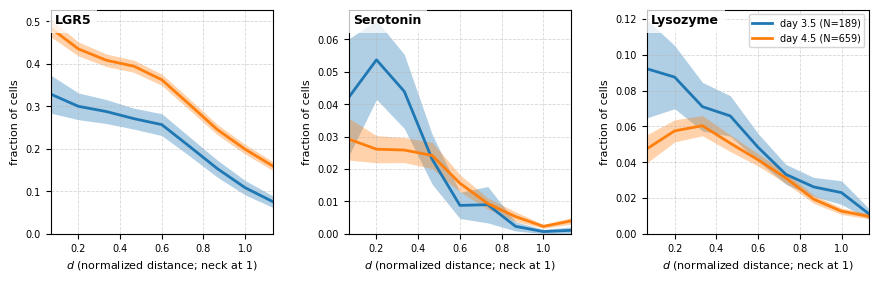

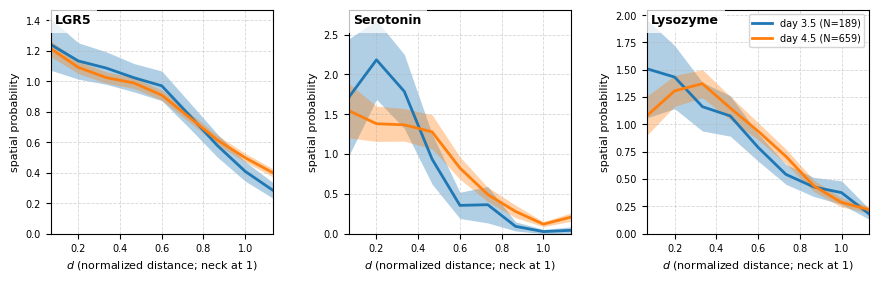

(<Figure size 920x270 with 3 Axes>,
 array([<Axes: xlabel='$d$ (normalized distance; neck at 1)', ylabel='spatial probability'>,
        <Axes: xlabel='$d$ (normalized distance; neck at 1)', ylabel='spatial probability'>,
        <Axes: xlabel='$d$ (normalized distance; neck at 1)', ylabel='spatial probability'>],
       dtype=object))

In [18]:
normalized_distance_binned = collect_binned_marker_profiles_from_table_multi(
    inspection_df=inspection_df,
    bin_edges=NORMALIZED_DISTANCE_BIN_EDGES,
    common_markers=common_markers,
    derived_marker_groups=DERIVED_MARKER_GROUPS,
)

meta = normalized_distance_binned["meta"]
group_masks = [(meta["sample_label"] == label).to_numpy() for label in SAMPLE_ORDER]
group_labels = SAMPLE_ORDER

fig, axes = plot_binned_marker_profiles_multi(
    normalized_distance_binned,
    target_markers=TARGET_MARKERS,
    group_masks=group_masks,
    group_labels=group_labels,
    fig_width=9.2,
    ncols=3,
    fill_alpha=0.35,
)
export_figure(fig, "marker_fraction_vs_normalized_geodesic_distance")

fig, axes = plot_binned_marker_profiles_multi(
    normalized_distance_binned,
    target_markers=TARGET_MARKERS,
    group_masks=group_masks,
    group_labels=group_labels,
    fig_width=9.2,
    ncols=3,
    fill_alpha=0.35,
    area_normalize=True,
)
export_figure(fig, "area_normalized_marker_fraction_vs_normalized_geodesic_distance")


### Fraction vs Graph Hops from Saved Bottom Cell

Distances are integer shortest-path lengths in the cell adjacency graph, measured from the crypt cell closest to the saved bottom. When available, the boundary panel shows the distribution of mean graph-hop distances from the bottom cell to sampled non-crypt cells adjacent to the crypt boundary.


For the second graph-hop figure, `Q_X(d)` is the shell-size-corrected shape-only distribution. First, marker-positive cells are pooled across crypts in a timepoint group to compute `P_X(d)`, and all cells are pooled to compute `P_all(d)`. Their ratio `E_X(d) = P_X(d) / P_all(d)` removes the radial shell-size effect, because large-distance shells often contain more cells. Finally, `Q_X(d) = E_X(d) / sum_d E_X(d)` rescales this enrichment profile to a distribution over distance. Values therefore show where marker `X` is enriched relative to the available cells at each hop distance.


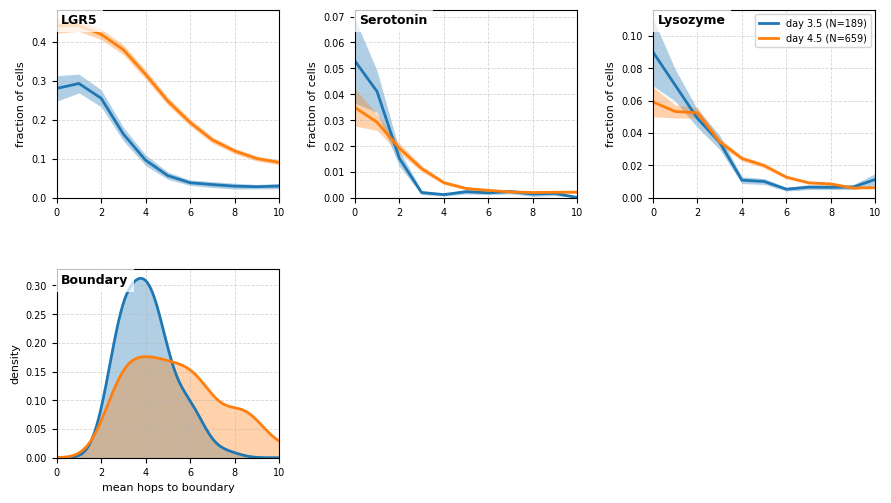

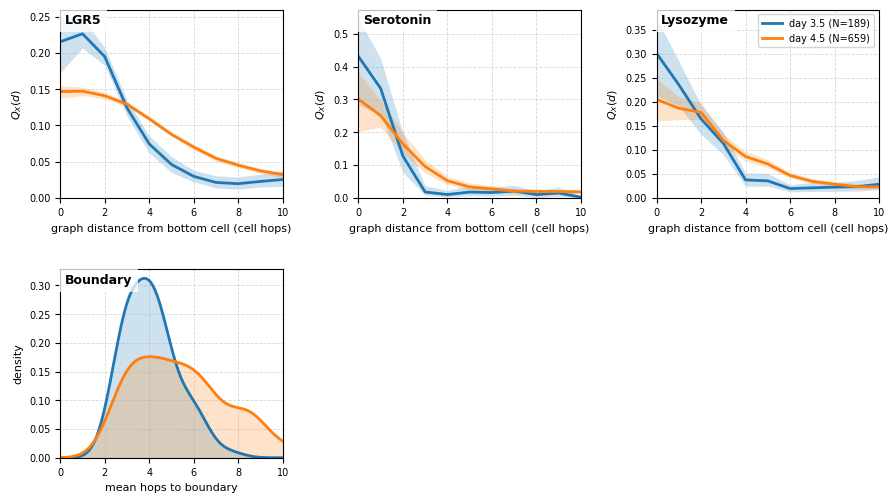

(<Figure size 920x540 with 6 Axes>,
 array([<Axes: xlabel='graph distance from bottom cell (cell hops)', ylabel='$Q_X(d)$'>,
        <Axes: xlabel='graph distance from bottom cell (cell hops)', ylabel='$Q_X(d)$'>,
        <Axes: xlabel='graph distance from bottom cell (cell hops)', ylabel='$Q_X(d)$'>,
        <Axes: xlabel='mean hops to boundary', ylabel='density'>, <Axes: >,
        <Axes: >], dtype=object))

In [19]:
hop_binned = collect_hop_marker_profiles_from_table_multi(
    inspection_df=inspection_df,
    common_markers=common_markers,
    derived_marker_groups=DERIVED_MARKER_GROUPS,
    max_hops=GRAPH_HOP_MAX,
    bottom_strategy="saved_bottom_cell",
)

meta = hop_binned["meta"]
group_masks = [(meta["sample_label"] == label).to_numpy() for label in SAMPLE_ORDER]
group_labels = SAMPLE_ORDER

fig, axes = plot_binned_marker_profiles_multi(
    hop_binned,
    target_markers=TARGET_MARKERS,
    group_masks=group_masks,
    group_labels=group_labels,
    fig_width=9.2,
    ncols=3,
    fill_alpha=0.35,
    xlabel="graph distance from bottom cell (cell hops)",
)
export_figure(fig, "marker_fraction_vs_graph_hops")

fig, axes = plot_shell_size_corrected_distribution_multi(
    hop_binned,
    target_markers=TARGET_MARKERS,
    group_masks=group_masks,
    group_labels=group_labels,
    n_boot=200,
    fig_width=9.2,
    ncols=3,
    xlabel="graph distance from bottom cell (cell hops)",
)
export_figure(fig, "shell_size_corrected_Qx_vs_graph_hops")



### Fraction vs Graph Hops from HKS-Optimized Bottom Cell

For each crypt, the mesh is smoothed with the first `l=10` Laplace-Beltrami eigenmodes. Within the bottom 50% of the saved mesh crypt axis, the vertex with highest HKS at `t=1` becomes the optimized bottom, and the nearest crypt cell is used as the graph-hop source.


In [20]:
# optimized_hop_binned = collect_hop_marker_profiles_from_table_multi(
#     inspection_df=inspection_df,
#     common_markers=common_markers,
#     derived_marker_groups=DERIVED_MARKER_GROUPS,
#     max_hops=GRAPH_HOP_MAX,
#     bottom_strategy="optimized_hks_bottom_cell",
#     smooth_lmax=10,
#     hks_time=1.0,
#     bottom_fraction=0.4,
# )

# meta = optimized_hop_binned["meta"]
# group_masks = [(meta["sample_label"] == label).to_numpy() for label in SAMPLE_ORDER]
# group_labels = SAMPLE_ORDER

# plot_binned_marker_profiles_multi(
#     optimized_hop_binned,
#     target_markers=TARGET_MARKERS,
#     group_masks=group_masks,
#     group_labels=group_labels,
#     fig_width=9.2,
#     ncols=3,
#     fill_alpha=0.35,
#     xlabel="graph distance from optimized bottom cell (cell hops)",
# )

# plot_binned_marker_profiles_multi(
#     optimized_hop_binned,
#     target_markers=TARGET_MARKERS,
#     group_masks=group_masks,
#     group_labels=group_labels,
#     fig_width=9.2,
#     ncols=3,
#     fill_alpha=0.35,
#     xlabel="graph distance from optimized bottom cell (cell hops)",
#     area_normalize=True,
# )
